In [60]:
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

In [54]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## load ins 

In [55]:
df = pd.read_csv("Data/ignore/panel_data.csv")
df = df.drop("DATE", axis = 1)

df['date'] = pd.to_datetime(df["date"])

df["date"] = df["date"].dt.floor("D")

df.columns = df.columns.str.lower()

df.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng,month,sid,season,name,max cat,start date,end date,storm duration,iso_time,nature,dist2land,landfall,usa_lat,usa_lon,usa_record,usa_status,usa_wind,usa_pres,usa_sshs,usa_poci,usa_roci,usa_rmw,usa_eye,usa_gust,usa_seahgt,storm_speed,storm_dir,distance,mid_delt,premium_delt,diesel_delt
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386207,0.374628,0.692300
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.384721,0.373229,0.687541
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383247,0.371841,0.682846
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.381783,0.370464,0.678215


## Covariate correlation check

<Axes: >

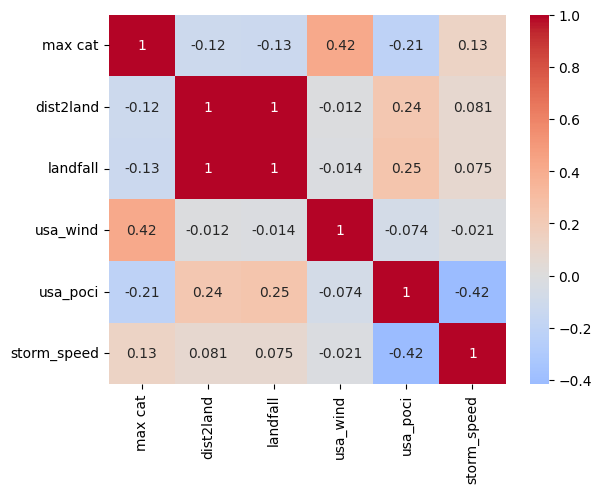

In [64]:
regressors = ["max cat", "dist2land", "landfall", "usa_wind", "usa_poci", "storm_speed"]
corr = df[regressors].corr()

sns.heatmap(corr, annot= True, cmap = "coolwarm", center=0)

**Key takeaways**

Cannot include both `dist2land` and `landfall` -> kept `dist2land`

`max_cat` and `usa_wind` are highly correlated 

Kept both `dist2land` and `usa_wind` because these are continuous. 

Pressure and storm speed are related but I kept both

## Storm

In [57]:
from src.storm_regression import storm_ols

In [58]:
df["name"].unique()

<StringArray>
[        nan,    'BONNIE',  'DANIELLE',     'FIONA',       'IAN',     'JULIA',
      'LISA',    'NICOLE',       'DON',  'FRANKLIN',       'LEE',     'NIGEL',
     'TAMMY',     'BERYL',     'DEBBY',   'ERNESTO',  'FRANCINE',    'HELENE',
     'ISAAC',      'KIRK',    'LESLIE',     'OSCAR',    'RAFAEL',      'ERIN',
 'GABRIELLE',  'HUMBERTO',    'IMELDA',   'MELISSA']
Length: 28, dtype: str

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.964
Date:                Sat, 04 Apr 2026   Prob (F-statistic):             0.0321
Time:                        16:58:25   Log-Likelihood:                 74.411
No. Observations:                 360   AIC:                            -140.8
Df Residuals:                     356   BIC:                            -125.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4623      0.059     -7.847      

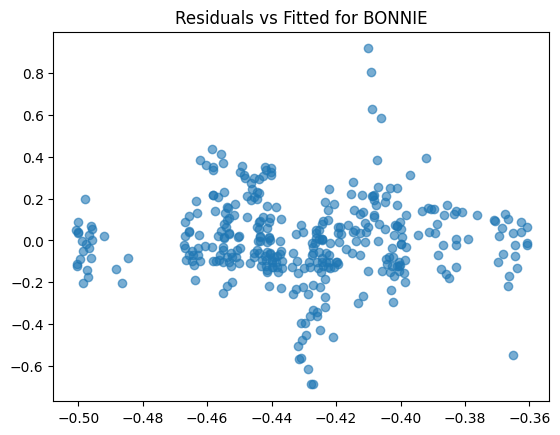

In [66]:
model_bonnie, df_bonnie = storm_ols(
    df = df,
    storm_name = 'BONNIE',
    outcome = "reg_delt",
    regressors = ["storm_speed", "distance", "dist2land"],
    diagnostic=True
)

In [67]:
df.columns

Index(['metro', 'date', 'regular', 'mid', 'premium', 'diesel', 'reg_delt',
       'met', 'lat', 'lng', 'month', 'sid', 'season', 'name', 'max cat',
       'start date', 'end date', 'storm duration', 'iso_time', 'nature',
       'dist2land', 'landfall', 'usa_lat', 'usa_lon', 'usa_record',
       'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_poci',
       'usa_roci', 'usa_rmw', 'usa_eye', 'usa_gust', 'usa_seahgt',
       'storm_speed', 'storm_dir', 'distance', 'mid_delt', 'premium_delt',
       'diesel_delt'],
      dtype='str')

                            OLS Regression Results                            
Dep. Variable:            diesel_delt   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     14.30
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           8.08e-09
Time:                        17:00:15   Log-Likelihood:                 185.85
No. Observations:                 360   AIC:                            -363.7
Df Residuals:                     356   BIC:                            -348.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4526      0.043    -10.469      

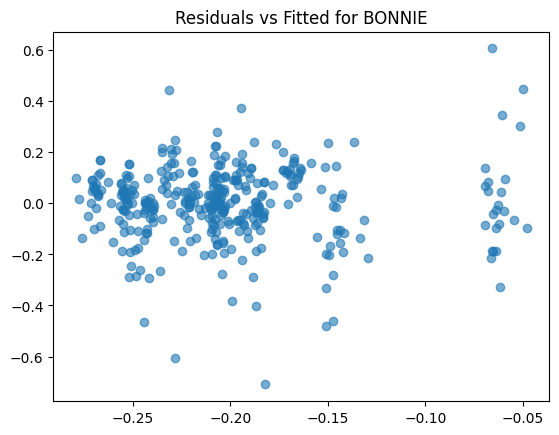

In [68]:
model_bonnie, df_bonnie = storm_ols(
    df = df,
    storm_name = 'BONNIE',
    outcome = "diesel_delt",
    regressors = ["storm_speed", "distance", "dist2land"],
    diagnostic=True
)

## Split

In [70]:
from src.storm_regression import ols_train_test

## Performance

In [95]:
r = ["dist2land", "usa_wind", "storm_speed"]
m =  'Miami-Fort Lauderdale-West Palm Beach'

model, performance = ols_train_test(df, m, "reg_delt", r, test_size = .2)

Rows in model_df: 762
X shape: (762, 3)
y shape: (762,)
                                0
observations           762.000000
observations in train  609.000000
observations in test   153.000000
train_rmse               0.603529
test_rmse                0.677309
train_r2                 0.021612
test_r2                 -0.038553


In [94]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.036
Date:                Sat, 04 Apr 2026   Prob (F-statistic):             0.0287
Time:                        18:29:21   Log-Likelihood:                -602.55
No. Observations:                 609   AIC:                             1213.
Df Residuals:                     605   BIC:                             1231.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1845      0.083      2.219      